## Setup & Imports

In [99]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from itertools import product
from scipy.optimize import minimize, basinhopping

SEED = 42
np.random.seed(SEED)

sns.set_style("ticks")
plt.rcParams.update({
    "figure.figsize":    (10, 5),
    "axes.titleweight":  "bold",
    "axes.titlesize":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.linestyle":    ":",
    "grid.alpha":        0.45,
    "font.family":       "DejaVu Sans",
})
ASSET_COLOURS = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
SEQ_A_C, SEQ_B_C = "#5b3a91", "#d68c45"
ACCENT, GOAL_C   = "#9d0208", "#0f7173"

def inr(x):
    if abs(x) >= 1e7:
        return f"₹{x/1e7:,.2f} Cr"
    if abs(x) >= 1e5:
        return f"₹{x/1e5:,.2f} L"
    return f"₹{x:,.0f}"


## Data Collection

Daily adjusted closes for the five tickers (TCS.NS, HDFCBANK.NS, RELIANCE.NS, SUNPHARMA.NS, ITC.NS) over the exact period **1-Jan-2014 to 31-Dec-2023**, pulled with `yfinance`.

In [100]:
TICKERS = ["TCS.NS", "HDFCBANK.NS", "RELIANCE.NS", "SUNPHARMA.NS", "ITC.NS"]
SECTORS = {
    "TCS.NS":       "IT",
    "HDFCBANK.NS":  "Financials",
    "RELIANCE.NS":  "Energy / Conglomerate",
    "SUNPHARMA.NS": "Healthcare",
    "ITC.NS":       "FMCG",
}
START, END = "2014-01-01", "2023-12-31"

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
# yfinance can return either a multi-index frame or a flat one depending on version
prices = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw
# strict: keep only days where every ticker has a real print (no forward-fill)
prices = prices.dropna()[TICKERS]

print(f"Date range : {prices.index.min().date()}  →  {prices.index.max().date()}")
print(f"Trading days: {len(prices)}")
prices.tail()


Date range : 2014-01-01  →  2023-12-29
Trading days: 2465


Ticker,TCS.NS,HDFCBANK.NS,RELIANCE.NS,SUNPHARMA.NS,ITC.NS
Date,,,,,
2023-12-22,3561.377441,813.178833,1273.102173,1213.404907,401.367279
2023-12-26,3534.881104,818.824463,1279.554443,1217.161255,402.469452
2023-12-27,3549.456055,828.971863,1283.922119,1221.990845,403.042603
2023-12-28,3538.931885,829.920837,1293.203369,1231.454956,409.214722
2023-12-29,3532.878906,831.867615,1282.979126,1228.820679,407.451294


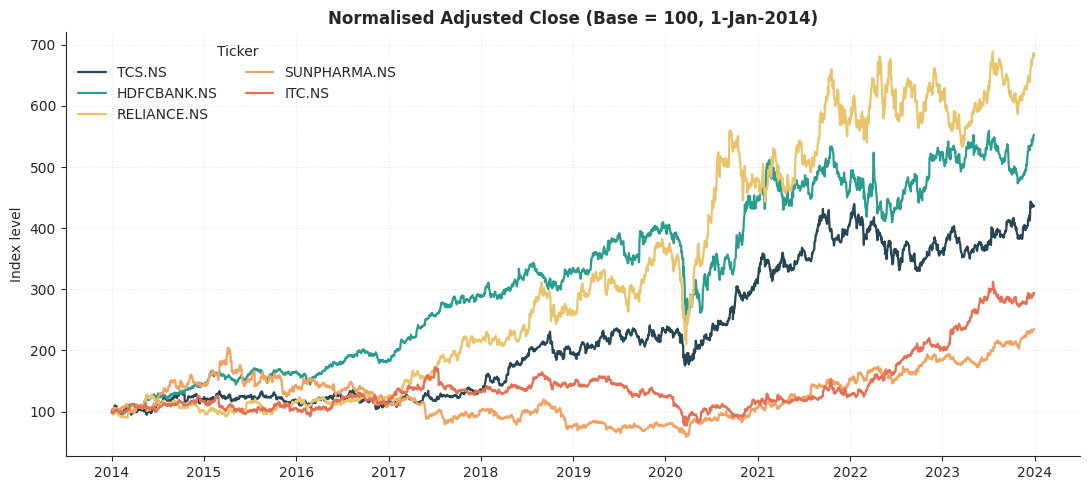

In [101]:
fig, ax = plt.subplots(figsize=(11, 5))
norm = (prices / prices.iloc[0] * 100)
for col, c in zip(norm.columns, ASSET_COLOURS):
    ax.plot(norm.index, norm[col], color=c, lw=1.6, label=col)
ax.set_title("Normalised Adjusted Close (Base = 100, 1-Jan-2014)")
ax.set_ylabel("Index level")
ax.set_xlabel("")
ax.legend(title="Ticker", loc="upper left", frameon=False, ncol=2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## Annualised return, risk & covariance

Computed from daily log-returns: $\mu_a = \bar{r} \times 252$, $\Sigma_a = \mathrm{cov}(r) \times 252$, $\sigma_a = \sqrt{\mathrm{diag}(\Sigma_a)}$. No external assumptions used.

In [102]:
TRADING_DAYS = 252
log_ret = np.log(prices / prices.shift(1)).dropna()

mu_annual    = log_ret.mean() * TRADING_DAYS
cov_annual   = log_ret.cov()  * TRADING_DAYS
sigma_annual = pd.Series(np.sqrt(np.diag(cov_annual.values)), index=cov_annual.index)
corr         = log_ret.corr()

stats = pd.DataFrame({
    "Sector":        [SECTORS[t] for t in TICKERS],
    "Ann. log-μ":    mu_annual.reindex(TICKERS).values,
    "Ann. simple μ": (np.exp(mu_annual.reindex(TICKERS).values) - 1),
    "Ann. σ":        sigma_annual.reindex(TICKERS).values,
}, index=TICKERS)
stats.style.format({"Ann. log-μ": "{:.2%}",
                    "Ann. simple μ": "{:.2%}",
                    "Ann. σ": "{:.2%}"})


,Sector,Ann. log-μ,Ann. simple μ,Ann. σ
TCS.NS,IT,15.05%,16.24%,24.04%
HDFCBANK.NS,Financials,17.49%,19.11%,22.46%
RELIANCE.NS,Energy / Conglomerate,19.62%,21.68%,27.77%
SUNPHARMA.NS,Healthcare,8.73%,9.12%,29.86%
ITC.NS,FMCG,11.00%,11.63%,25.48%


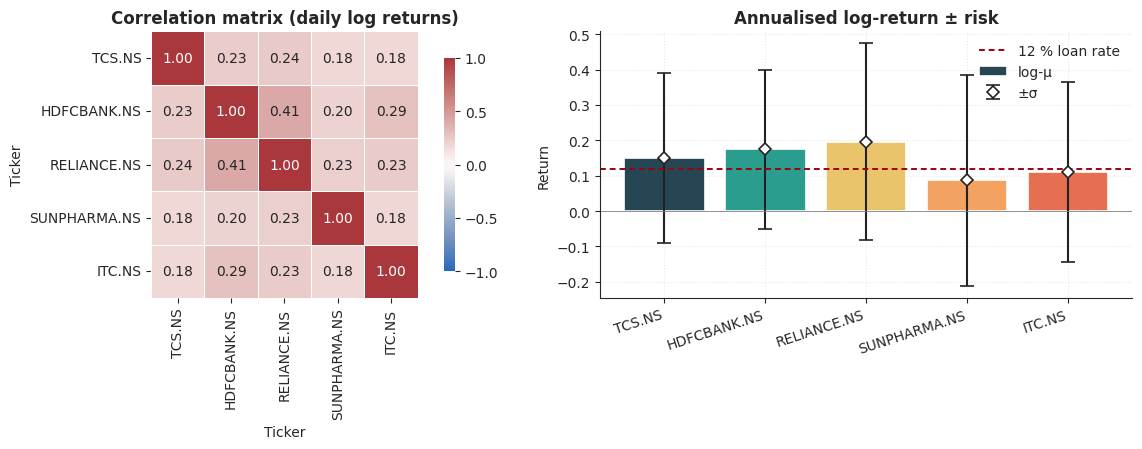

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True,
            linewidths=0.6, linecolor="white",
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation matrix (daily log returns)")

axes[1].bar(stats.index, stats["Ann. log-μ"], color=ASSET_COLOURS,
            edgecolor="white", linewidth=1.2, label="log-μ")
axes[1].errorbar(stats.index, stats["Ann. log-μ"],
                 yerr=stats["Ann. σ"], fmt="D", color="#222222",
                 markerfacecolor="white", markeredgewidth=1.2,
                 capsize=5, label="±σ")
axes[1].axhline(0.12, color=ACCENT, ls=(0, (3, 2)), lw=1.4,
                label="12 % loan rate")
axes[1].axhline(0, color="grey", lw=0.6)
axes[1].set_title("Annualised log-return ± risk")
axes[1].set_ylabel("Return")
axes[1].legend(frameon=False)
plt.setp(axes[1].get_xticklabels(), rotation=18, ha="right")
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()


## Part 1: Goal Sequences

Two goal sequences over a 20-year horizon, each with three intermediate goals plus a terminal retirement goal of ₹1.5 Cr at Y20.

**Sequence A — Aggressive Early Goals**
- Goal 1: ₹15 Lakhs at Year 3
- Goal 2: ₹25 Lakhs at Year 7
- Goal 3: ₹30 Lakhs at Year 12
- Terminal Goal (Retirement): ₹1.5 Crores at Year 20

**Sequence B — Backloaded Goals**
- Goal 1: ₹10 Lakhs at Year 8
- Goal 2: ₹20 Lakhs at Year 12
- Goal 3: ₹40 Lakhs at Year 16
- Terminal Goal (Retirement): ₹1.5 Crores at Year 20

Financial constraints applied throughout:
- Initial savings: ₹20,000 / month, growing at 4 % annually
- Borrowing penalty: 12 % effective annual rate on any shortfall

In [104]:
HORIZON_YEARS    = 20
MONTHS           = HORIZON_YEARS * 12
MONTHLY_SAVING_0 = 20_000.0                       # ₹/month, year 1
SAVINGS_GROWTH   = 0.04                           # +4 % p.a.
BORROW_APR       = 0.12                           # 12 % effective annual
BORROW_MO        = (1 + BORROW_APR) ** (1/12) - 1
TERMINAL_GOAL    = 1.5e7                          # ₹1.5 Crore
N_PATHS          = 5_000

# intermediate goals only — terminal is checked separately
SEQUENCE_A = {3: 15e5, 7: 25e5, 12: 30e5}
SEQUENCE_B = {8: 10e5, 12: 20e5, 16: 40e5}

# 4 % step at year boundaries (months 12, 24, …)
SAVINGS = np.array(
    [MONTHLY_SAVING_0 * (1 + SAVINGS_GROWTH) ** (m // 12) for m in range(MONTHS)]
)

print("Sequence A:", {f"Y{y}": inr(a) for y, a in SEQUENCE_A.items()},
      "+ Terminal", inr(TERMINAL_GOAL))
print("Sequence B:", {f"Y{y}": inr(a) for y, a in SEQUENCE_B.items()},
      "+ Terminal", inr(TERMINAL_GOAL))
print(f"\nMonthly loan rate = {BORROW_MO*100:.4f} %  (= (1.12)^(1/12) − 1)")
print(f"Total contributions over 20 yrs (nominal): {inr(SAVINGS.sum())}")


Sequence A: {'Y3': '₹15.00 L', 'Y7': '₹25.00 L', 'Y12': '₹30.00 L'} + Terminal ₹1.50 Cr
Sequence B: {'Y8': '₹10.00 L', 'Y12': '₹20.00 L', 'Y16': '₹40.00 L'} + Terminal ₹1.50 Cr

Monthly loan rate = 0.9489 %  (= (1.12)^(1/12) − 1)
Total contributions over 20 yrs (nominal): ₹71.47 L


### A few modelling choices
- **Monthly grid** (240 steps) — savings are monthly, so this is the natural unit.
- **Each month:** savings → growth → debt interest → goal payment → sweep any cash to the loan.
- **Goals** land at month $12y-1$. If cash is short, only the gap is borrowed.
- **Returns** are lognormal: $r_p = \exp(z)$, $z \sim \mathcal{N}(w^\top\mu_m,\, w^\top\Sigma_m w)$, with monthly stats = annual / 12.
- **Savings** step up 4 % at each year boundary; **loan rate** is the monthly equivalent of 12 % effective, $(1.12)^{1/12}-1$.
- **Success:** $A_{240} - D_{240} \ge$ ₹1.5 Cr.
- **Seed 42** is reused for every portfolio so the ranking reflects allocation, not random noise.

## Part 2: Portfolio Simulation & Optimization

A static portfolio that remains unchanged throughout the 20-year horizon.

### Task 2.1: Discrete Weight Allocation

Generate every possible portfolio combination using only the discrete weights $\{0,\,0.25,\,0.5,\,0.75,\,1.0\}$ across the 5 securities, retaining only those that sum to **exactly 1.0** — that gives 70$ portfolios.

In [105]:
DISCRETE_WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0]

combinations = np.array([
    w for w in product(DISCRETE_WEIGHTS, repeat=len(TICKERS))
    if abs(sum(w) - 1.0) < 1e-9
])
print(f"Valid discrete portfolios: {len(combinations)}")
pd.DataFrame(combinations, columns=TICKERS).head(8)


Valid discrete portfolios: 70


,TCS.NS,HDFCBANK.NS,RELIANCE.NS,SUNPHARMA.NS,ITC.NS
0,0.0,0.0,0.00,0.00,1.00
1,0.0,0.0,0.00,0.25,0.75
2,0.0,0.0,0.00,0.50,0.50
3,0.0,0.0,0.00,0.75,0.25
4,0.0,0.0,0.00,1.00,0.00
5,0.0,0.0,0.25,0.00,0.75
6,0.0,0.0,0.25,0.25,0.50
7,0.0,0.0,0.25,0.50,0.25


### Task 2.2: Monte Carlo Simulation

For every valid discrete weight combination, run a Monte Carlo simulation with exactly **5,000 paths**. Apply the annual 4 % savings increase, deduct goal amounts at their respective years, and apply the 12 % borrowing logic if a path falls short of an intermediate goal.

In [106]:
mu_m_vec  = (mu_annual.reindex(TICKERS).values) / 12.0
cov_m_mat = (cov_annual.reindex(index=TICKERS, columns=TICKERS).values) / 12.0

def goal_months(seq):
    # year y → month index 12y - 1 (end of year y, 0-indexed)
    return {12 * y - 1: amt for y, amt in seq.items()}

def simulate(weights, seq, n_paths=N_PATHS, seed=SEED, return_history=False):
    w = np.asarray(weights, dtype=float)
    p_mu  = float(w @ mu_m_vec)
    p_var = max(float(w @ cov_m_mat @ w), 1e-14)
    p_sd  = np.sqrt(p_var)

    rng = np.random.default_rng(seed)
    growth = np.exp(rng.normal(p_mu, p_sd, size=(n_paths, MONTHS)))
    gmap = goal_months(seq)

    A = np.zeros(n_paths)
    D = np.zeros(n_paths)
    H = np.zeros((n_paths, MONTHS + 1)) if return_history else None

    for t in range(MONTHS):
        # savings + asset growth this month
        A += SAVINGS[t]
        A *= growth[:, t]
        # debt accrues
        D *= (1 + BORROW_MO)
        # if a goal is due: pay from cash, borrow only the shortfall
        if t in gmap:
            g = gmap[t]
            covered = A >= g
            short = np.where(covered, 0.0, g - A)
            A = np.where(covered, A - g, 0.0)
            D = D + short
        # any positive cash repays outstanding debt
        repay = np.minimum(A, D)
        A -= repay; D -= repay
        if return_history:
            H[:, t + 1] = A - D

    nw = A - D
    return (nw, H) if return_history else nw

def p_success(weights, seq):
    return float(np.mean(simulate(weights, seq) >= TERMINAL_GOAL))


### Task 2.3: Maximizing Success

For each portfolio combination, compute the probability of reaching the ₹1.5 Cr terminal retirement goal. Brute-force over all 70 portfolios to identify the single combination with the highest success probability — separately for Sequence A and Sequence B.

In [107]:
def brute_force(combos, seq, label):
    rows = [list(w) + [p_success(w, seq)] for w in combos]
    df = (pd.DataFrame(rows, columns=TICKERS + ["P_success"])
            .sort_values("P_success", ascending=False)
            .reset_index(drop=True))
    print(f"\n>>> {label}: top 10 portfolios by P(reach ₹1.5 Cr)")
    fmt = {c: "{:.2f}".format for c in TICKERS}
    fmt["P_success"] = "{:.4f}".format
    print(df.head(10).to_string(index=False, formatters=fmt))
    return df

results_A = brute_force(combinations, SEQUENCE_A, "Sequence A")
results_B = brute_force(combinations, SEQUENCE_B, "Sequence B")



>>> Sequence A: top 10 portfolios by P(reach ₹1.5 Cr)
TCS.NS HDFCBANK.NS RELIANCE.NS SUNPHARMA.NS ITC.NS P_success
  0.00        0.00        1.00         0.00   0.00    0.0308
  0.00        0.25        0.75         0.00   0.00    0.0140
  0.25        0.00        0.75         0.00   0.00    0.0104
  0.00        0.00        0.75         0.00   0.25    0.0068
  0.00        0.00        0.75         0.25   0.00    0.0062
  0.00        1.00        0.00         0.00   0.00    0.0058
  0.00        0.50        0.50         0.00   0.00    0.0058
  0.00        0.75        0.25         0.00   0.00    0.0036
  1.00        0.00        0.00         0.00   0.00    0.0032
  0.25        0.25        0.50         0.00   0.00    0.0024

>>> Sequence B: top 10 portfolios by P(reach ₹1.5 Cr)
TCS.NS HDFCBANK.NS RELIANCE.NS SUNPHARMA.NS ITC.NS P_success
  0.00        0.50        0.50         0.00   0.00    0.8222
  0.00        0.25        0.75         0.00   0.00    0.8214
  0.00        0.00        1.00      

In [108]:
def show_optimum(results, label):
    best = results.iloc[0]
    w = best[TICKERS].values.astype(float)
    p = float(best["P_success"])
    print(f"\n=== Optimal static portfolio — {label} ===")
    for t, wt in zip(TICKERS, w):
        print(f"  {t:13s} ({SECTORS[t]:<22s}): {wt*100:5.1f}%")
    print(f"  → Probability of reaching ₹1.5 Cr: {p:.2%}")
    return w, p

w_A, p_A = show_optimum(results_A, "Sequence A (aggressive early)")
w_B, p_B = show_optimum(results_B, "Sequence B (back-loaded)")



=== Optimal static portfolio — Sequence A (aggressive early) ===
  TCS.NS        (IT                    ):   0.0%
  HDFCBANK.NS   (Financials            ):   0.0%
  RELIANCE.NS   (Energy / Conglomerate ): 100.0%
  SUNPHARMA.NS  (Healthcare            ):   0.0%
  ITC.NS        (FMCG                  ):   0.0%
  → Probability of reaching ₹1.5 Cr: 3.08%

=== Optimal static portfolio — Sequence B (back-loaded) ===
  TCS.NS        (IT                    ):   0.0%
  HDFCBANK.NS   (Financials            ):  50.0%
  RELIANCE.NS   (Energy / Conglomerate ):  50.0%
  SUNPHARMA.NS  (Healthcare            ):   0.0%
  ITC.NS        (FMCG                  ):   0.0%
  → Probability of reaching ₹1.5 Cr: 82.22%


### Optimal portfolios

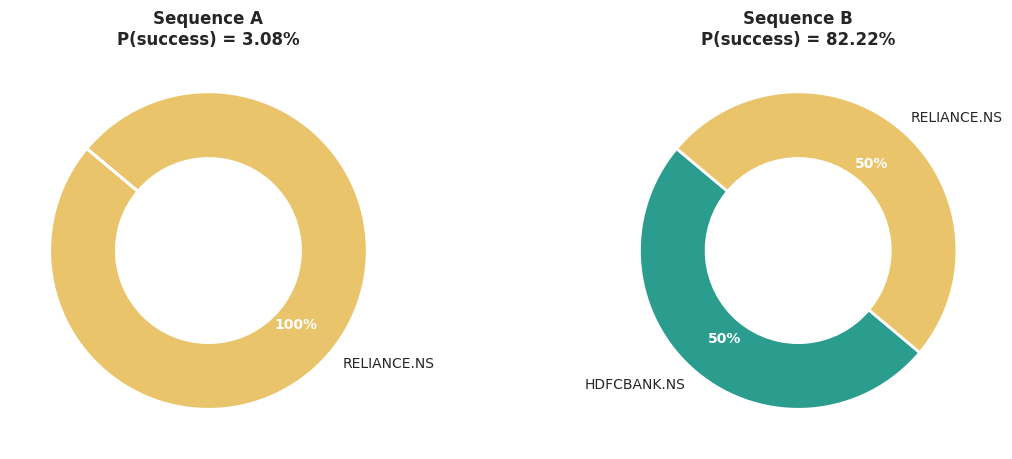

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for ax, w, label, p in zip(axes, [w_A, w_B], ["Sequence A", "Sequence B"], [p_A, p_B]):
    mask = w > 0
    sizes  = w[mask]
    names  = [t for t, m in zip(TICKERS, mask) if m]
    cols   = [ASSET_COLOURS[i] for i, m in enumerate(mask) if m]
    wedges, texts, autos = ax.pie(
        sizes, labels=names, colors=cols, autopct="%1.0f%%",
        startangle=140, pctdistance=0.72,
        wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.42},
        textprops={"fontsize": 10},
    )
    for a in autos:
        a.set_color("white"); a.set_fontweight("bold")
    ax.set_title(f"{label}\nP(success) = {p:.2%}")
plt.tight_layout()
plt.show()


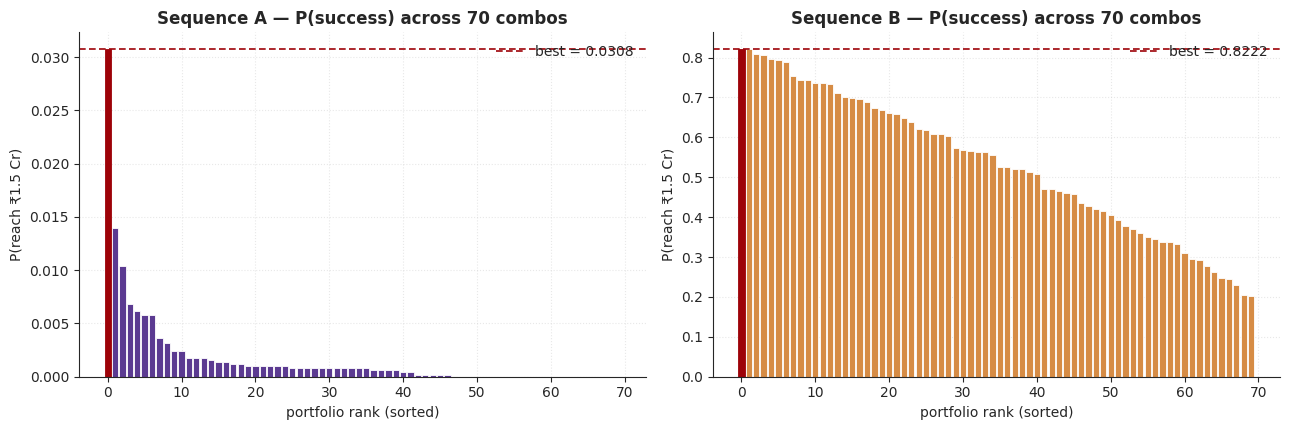

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, df, title, colour in [
    (axes[0], results_A, "Sequence A", SEQ_A_C),
    (axes[1], results_B, "Sequence B", SEQ_B_C),
]:
    rank = np.arange(len(df))
    bars = ax.bar(rank, df["P_success"].values, color=colour,
                  edgecolor="white", linewidth=0.6, width=0.85)
    bars[0].set_color(ACCENT)        # highlight the winner
    ax.axhline(df["P_success"].max(), ls=(0, (4, 2)), color=ACCENT, lw=1.2,
               label=f"best = {df['P_success'].max():.4f}")
    ax.set_title(f"{title} — P(success) across 70 combos")
    ax.set_xlabel("portfolio rank (sorted)")
    ax.set_ylabel("P(reach ₹1.5 Cr)")
    ax.legend(frameon=False, loc="upper right")
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### Path behaviour

Terminal-wealth distribution and 200 sample wealth trajectories per sequence.

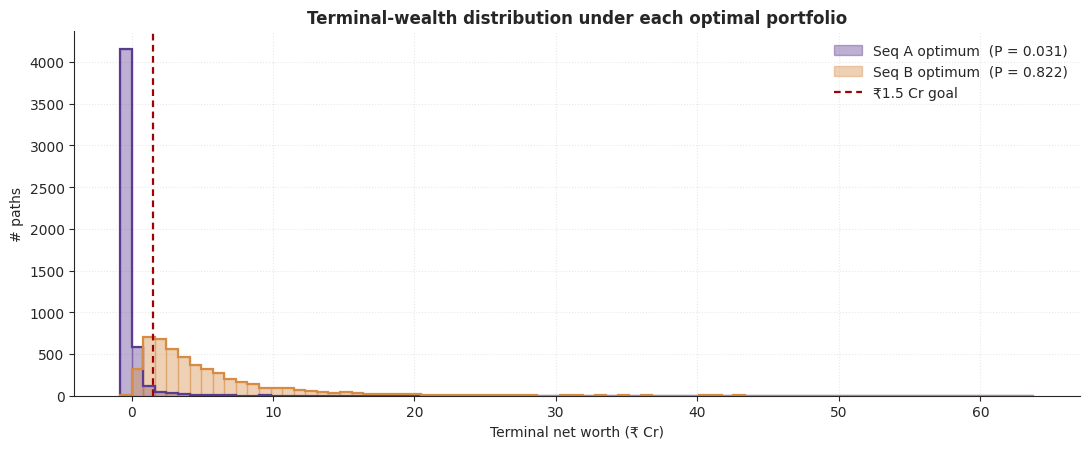

In [111]:
nw_A = simulate(w_A, SEQUENCE_A)
nw_B = simulate(w_B, SEQUENCE_B)

fig, ax = plt.subplots(figsize=(11, 4.6))
bins = np.linspace(min(nw_A.min(), nw_B.min(), 0),
                   max(nw_A.max(), nw_B.max()), 80) / 1e7

ax.hist(nw_A / 1e7, bins=bins, color=SEQ_A_C, alpha=0.40,
        label=f"Seq A optimum  (P = {p_A:.3f})", edgecolor=SEQ_A_C, linewidth=1.0)
ax.hist(nw_B / 1e7, bins=bins, color=SEQ_B_C, alpha=0.40,
        label=f"Seq B optimum  (P = {p_B:.3f})", edgecolor=SEQ_B_C, linewidth=1.0)
ax.hist(nw_A / 1e7, bins=bins, histtype="step", color=SEQ_A_C, lw=1.6)
ax.hist(nw_B / 1e7, bins=bins, histtype="step", color=SEQ_B_C, lw=1.6)

ax.axvline(TERMINAL_GOAL / 1e7, color=ACCENT, ls=(0, (3, 2)), lw=1.6,
           label="₹1.5 Cr goal")
ax.set_xlabel("Terminal net worth (₹ Cr)")
ax.set_ylabel("# paths")
ax.set_title("Terminal-wealth distribution under each optimal portfolio")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


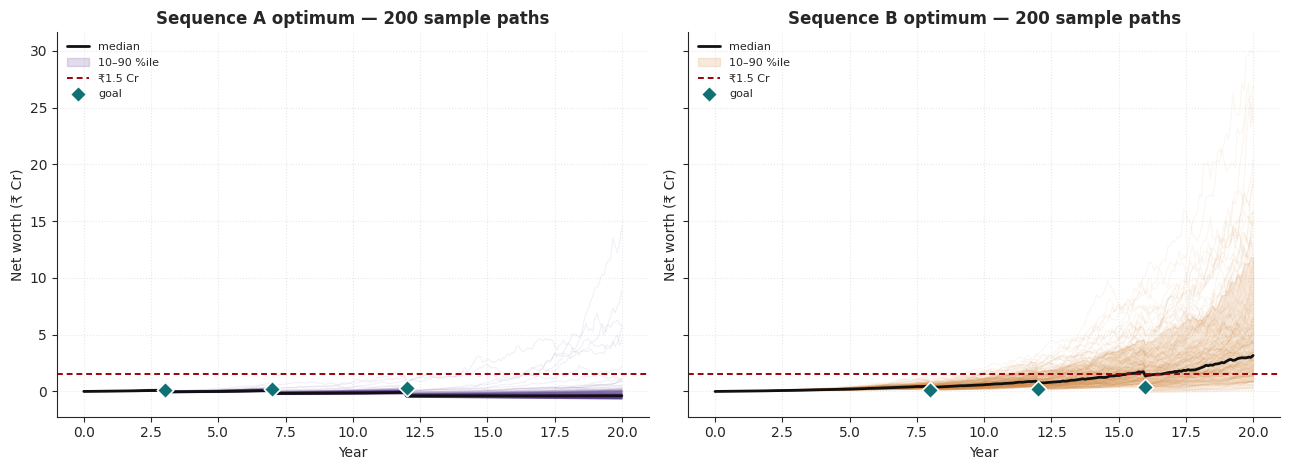

In [112]:
_, hA = simulate(w_A, SEQUENCE_A, n_paths=200, seed=1, return_history=True)
_, hB = simulate(w_B, SEQUENCE_B, n_paths=200, seed=1, return_history=True)
t_axis = np.arange(MONTHS + 1) / 12

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
panels = [(axes[0], hA, SEQUENCE_A, "Sequence A optimum", SEQ_A_C),
          (axes[1], hB, SEQUENCE_B, "Sequence B optimum", SEQ_B_C)]
for ax, h, seq, title, c in panels:
    ax.plot(t_axis, h.T / 1e7, color=c, alpha=0.08, lw=0.8)
    ax.plot(t_axis, np.median(h, axis=0) / 1e7, color="#101010",
            lw=2.0, label="median")
    ax.fill_between(t_axis,
                    np.percentile(h, 10, axis=0) / 1e7,
                    np.percentile(h, 90, axis=0) / 1e7,
                    color=c, alpha=0.18, label="10–90 %ile")
    ax.axhline(TERMINAL_GOAL / 1e7, color=ACCENT, ls=(0, (3, 2)),
               lw=1.4, label="₹1.5 Cr")
    first = True
    for y, amt in seq.items():
        ax.scatter([y], [amt / 1e7], marker="D", s=70,
                   facecolor=GOAL_C, edgecolor="white", linewidth=1.2,
                   zorder=6, label="goal" if first else None)
        first = False
    ax.set_title(f"{title} — 200 sample paths")
    ax.set_xlabel("Year")
    ax.set_ylabel("Net worth (₹ Cr)")
    ax.legend(loc="upper left", fontsize=8, frameon=False)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## Bonus (Optional): Continuous Weights with Short-Selling

We use `scipy.optimize.basinhopping` — a global solver — wrapping `minimize` with `method="SLSQP"` as its local polish. At every iteration `basinhopping` perturbs the current weights by a random kick (`stepsize = 0.4`); the inner SLSQP solve then re-enforces $\sum_i w_i = 1$ exactly. This combination explores the constrained surface globally while keeping each candidate at a feasible point, and the bounded kick size keeps the search to a sensible neighbourhood without imposing any explicit cap on weights.

In [113]:
SUM1 = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}

def neg_p(w, seq):
    return -p_success(w, seq)

def optimise(seq, label, x0_disc):
    """basinhopping (global random kicks) + SLSQP (constrained local polish).
    The only constraint is Σwᵢ = 1; no weight bounds."""
    minimizer_kwargs = {
        "method": "SLSQP",
        "constraints": [SUM1],
        "args": (seq,),
        "options": {"maxiter": 80, "ftol": 1e-6},
    }
    res = basinhopping(
        neg_p, x0=np.asarray(x0_disc, dtype=float),
        minimizer_kwargs=minimizer_kwargs,
        niter=15, stepsize=0.4, seed=SEED,
    )
    print(f"--- {label} ---")
    print(f"  P_success : {-res.fun:.4f}")
    print(f"  weights   : {np.round(res.x, 3)}")
    print(f"  Σw        : {res.x.sum():.4f}")
    return res.x, -res.fun

w_A_cont, p_A_cont = optimise(SEQUENCE_A, "Sequence A", w_A)
w_B_cont, p_B_cont = optimise(SEQUENCE_B, "Sequence B", w_B)


--- Sequence A ---
  P_success : 0.2236
  weights   : [-0.03   0.502  1.347 -0.05  -0.769]
  Σw        : 1.0000
--- Sequence B ---
  P_success : 0.8942
  weights   : [ 0.14   0.678  0.698 -0.093 -0.424]
  Σw        : 1.0000


In [114]:
summary = pd.DataFrame({
    "Discrete A":   list(w_A)      + [p_A],
    "Continuous A": list(w_A_cont) + [p_A_cont],
    "Discrete B":   list(w_B)      + [p_B],
    "Continuous B": list(w_B_cont) + [p_B_cont],
}, index=TICKERS + ["P(success)"])
summary.style.format("{:.4f}")


,Discrete A,Continuous A,Discrete B,Continuous B
TCS.NS,0.0000,-0.0303,0.0000,0.1404
HDFCBANK.NS,0.0000,0.5022,0.5000,0.6782
RELIANCE.NS,1.0000,1.3472,0.5000,0.6982
SUNPHARMA.NS,0.0000,-0.0505,0.0000,-0.0928
ITC.NS,0.0000,-0.7686,0.0000,-0.4240
P(success),0.0308,0.2236,0.8222,0.8942


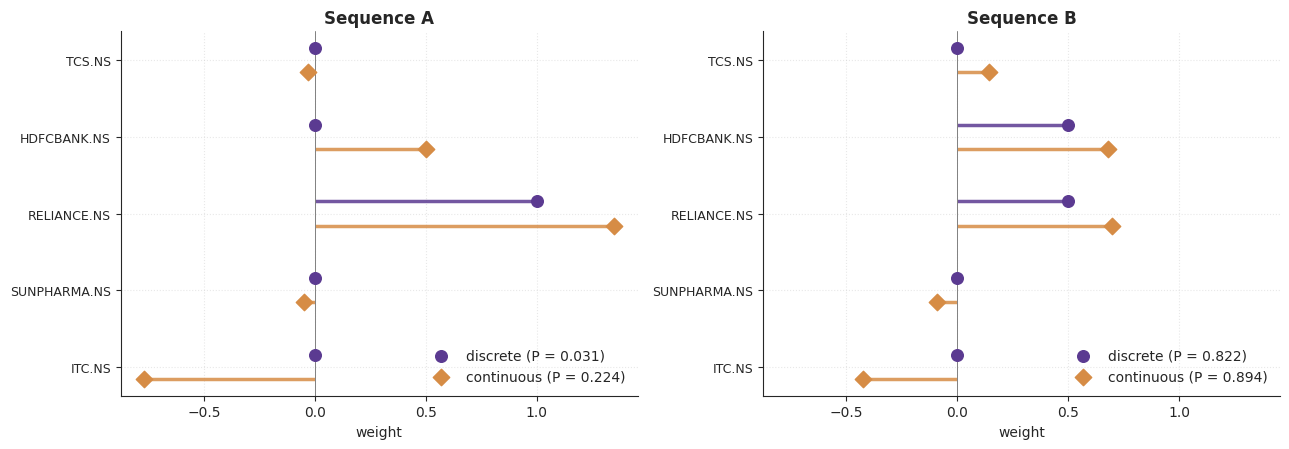

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
y = np.arange(len(TICKERS))
for ax, w_d, w_c, title, p_d, p_c in [
    (axes[0], w_A, w_A_cont, "Sequence A", p_A, p_A_cont),
    (axes[1], w_B, w_B_cont, "Sequence B", p_B, p_B_cont),
]:
    ax.hlines(y - 0.16, 0, w_d, colors=SEQ_A_C, lw=2.5, alpha=0.85)
    ax.scatter(w_d, y - 0.16, color=SEQ_A_C, s=70, zorder=5,
               label=f"discrete (P = {p_d:.3f})")
    ax.hlines(y + 0.16, 0, w_c, colors=SEQ_B_C, lw=2.5, alpha=0.85)
    ax.scatter(w_c, y + 0.16, color=SEQ_B_C, s=70, marker="D", zorder=5,
               label=f"continuous (P = {p_c:.3f})")
    ax.axvline(0, color="grey", lw=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(TICKERS, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("weight")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()
